# Modélisation — Assignment 3

Ce notebook charge les données produites par `preprocessing.ipynb` et entraîne les 3 modèles.  
**Aucune transformation des données n'est refaite ici.**

## Prérequis

Avoir exécuté `preprocessing.ipynb` au préalable — les fichiers suivants doivent exister :

```
data/processed/student_train.csv      ← scalé  (Régression Logistique)
data/processed/student_test.csv       ← scalé
data/processed/student_train_raw.csv  ← non scalé (RF, Gradient Boosting)
data/processed/student_test_raw.csv   ← non scalé
```

## Protocole d'évaluation

- **Split** : 80/20 stratifié (fait dans preprocessing.ipynb)
- **Validation** : cross-validation 5-fold stratifiée sur le train
- **Optimisation** : GridSearchCV sur F1-macro
- **Métrique principale** : F1-Score macro (classes déséquilibrées 78%/22%)
- **Test set** : touché une seule fois, à la fin, pour l'évaluation finale


## 1. Setup

In [1]:
%matplotlib inline

import sys, warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay, classification_report,
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
np.random.seed(42)

RANDOM_STATE = 42
NB_DIR       = Path.cwd()
DATA_DIR     = NB_DIR.parent / 'data' / 'processed'
MODELS_DIR   = NB_DIR.parent / 'models'
RESULTS_DIR  = NB_DIR.parent / 'results'
PLOTS_DIR    = NB_DIR.parent / 'plots'
RESULTS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
print('Setup ✓')

Setup ✓


## 2. Chargement des données

On charge directement les fichiers produits par `preprocessing.ipynb`.  
- **Scalé** → Régression Logistique  
- **Non scalé** → Random Forest et Gradient Boosting (les arbres sont insensibles au scaling)


In [2]:
# Scalé — pour Régression Logistique
train_s = pd.read_csv(DATA_DIR / 'student_train.csv')
test_s  = pd.read_csv(DATA_DIR / 'student_test.csv')

X_train_s = train_s.drop(columns=['pass'])
y_train   = train_s['pass']
X_test_s  = test_s.drop(columns=['pass'])
y_test    = test_s['pass']

# Non scalé — pour RF et GB
train_r = pd.read_csv(DATA_DIR / 'student_train_raw.csv')
test_r  = pd.read_csv(DATA_DIR / 'student_test_raw.csv')

X_train_r = train_r.drop(columns=['pass'])
X_test_r  = test_r.drop(columns=['pass'])

print(f'Train scalé    : {X_train_s.shape}  |  Test scalé    : {X_test_s.shape}')
print(f'Train non scalé: {X_train_r.shape}  |  Test non scalé: {X_test_r.shape}')
print(f'\nDistribution cible — train: {y_train.mean()*100:.1f}% pass | test: {y_test.mean()*100:.1f}% pass')
print(f'Features ({X_train_s.shape[1]}) :')
for i, c in enumerate(X_train_s.columns, 1):
    print(f'  {i:2d}. {c}')


Train scalé    : (835, 50)  |  Test scalé    : (209, 50)
Train non scalé: (835, 50)  |  Test non scalé: (209, 50)

Distribution cible — train: 78.0% pass | test: 78.0% pass
Features (50) :
   1. school
   2. sex
   3. age
   4. address
   5. famsize
   6. Pstatus
   7. traveltime
   8. studytime
   9. failures
  10. schoolsup
  11. famsup
  12. paid
  13. activities
  14. nursery
  15. higher
  16. internet
  17. romantic
  18. famrel
  19. freetime
  20. goout
  21. health
  22. absences
  23. alc_total
  24. alc_high_risk
  25. parent_edu
  26. study_vs_social
  27. motivated_with_resources
  28. family_capital
  29. has_support
  30. digital_access
  31. risk_score
  32. Mjob_at_home
  33. Mjob_health
  34. Mjob_other
  35. Mjob_services
  36. Mjob_teacher
  37. Fjob_at_home
  38. Fjob_health
  39. Fjob_other
  40. Fjob_services
  41. Fjob_teacher
  42. reason_course
  43. reason_home
  44. reason_other
  45. reason_reputation
  46. guardian_father
  47. guardian_mother
  48. guardi

## 3. Protocole d'évaluation

In [3]:
def compute_metrics(y_true, y_pred):
    """Métriques standard — écrites dans results/model_metrics.csv."""
    return {
        'f1_macro':  round(float(f1_score(y_true, y_pred, average='macro')), 4),
        'f1_class0': round(float(f1_score(y_true, y_pred, average=None)[0]), 4),
        'f1_class1': round(float(f1_score(y_true, y_pred, average=None)[1]), 4),
        'precision': round(float(precision_score(y_true, y_pred, average='macro', zero_division=0)), 4),
        'recall':    round(float(recall_score(y_true, y_pred, average='macro', zero_division=0)), 4),
        'accuracy':  round(float(accuracy_score(y_true, y_pred)), 4),
    }

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
all_results = {}

def evaluate_on_test(name, model, X_te, y_te):
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    metrics = compute_metrics(y_te, y_pred)
    metrics['model']   = name
    if y_proba is not None:
        metrics['roc_auc'] = round(roc_auc_score(y_te, y_proba), 4)
    all_results[name] = {'model': model, 'metrics': metrics,
                         'y_pred': y_pred, 'y_proba': y_proba}
    return metrics

print('Protocole défini ✓')
print(f'  CV : 5-fold stratifiée, random_state={RANDOM_STATE}')
print(f'  Métrique d\'optimisation : f1_macro')


Protocole défini ✓
  CV : 5-fold stratifiée, random_state=42
  Métrique d'optimisation : f1_macro


In [4]:
# Baseline — DummyClassifier
dummy_mf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_st = DummyClassifier(strategy='stratified',    random_state=RANDOM_STATE)

dummy_mf.fit(X_train_s, y_train)
dummy_st.fit(X_train_s, y_train)

m_mf = evaluate_on_test('dummy_most_frequent', dummy_mf, X_test_s, y_test)
m_st = evaluate_on_test('dummy_stratified',    dummy_st, X_test_s, y_test)

print('Baseline (plancher de performance) :')
print(f'  DummyClassifier most_frequent : F1 macro = {m_mf["f1_macro"]:.4f}')
print(f'  DummyClassifier stratified    : F1 macro = {m_st["f1_macro"]:.4f}')
print('  → Tout modèle utile doit dépasser ces valeurs.')


Baseline (plancher de performance) :
  DummyClassifier most_frequent : F1 macro = 0.4382
  DummyClassifier stratified    : F1 macro = 0.4873
  → Tout modèle utile doit dépasser ces valeurs.


## 4. Modèle 1 — Régression Logistique

**Hypothèses** : relation linéaire entre les features (scalées) et le log-odds de la cible.  
**Avantages** : interprétable (coefficients lisibles), rapide, bon baseline.  
**Limites** : incapable de capturer les interactions non-linéaires.  
**Adéquation** : idéal comme modèle de référence interprétable. Les coefficients permettent d'expliquer les prédictions à des parties prenantes non-techniques (directeurs d'école).


In [5]:
# Default — CV score
lr_default = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
from sklearn.model_selection import cross_val_score
cv_lr = cross_val_score(lr_default, X_train_s, y_train, cv=CV, scoring='f1_macro')
print(f'Régression Logistique (défaut) — CV F1 macro : {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')


Régression Logistique (défaut) — CV F1 macro : 0.6345 ± 0.0609


In [6]:
# GridSearchCV
lr_grid = {
    'C':       [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear'],
}
lr_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    lr_grid, scoring='f1_macro', cv=CV, n_jobs=-1, refit=True
)
lr_search.fit(X_train_s, y_train)

print(f'Meilleurs paramètres : {lr_search.best_params_}')
print(f'Meilleur CV F1 macro : {lr_search.best_score_:.4f}')


Meilleurs paramètres : {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Meilleur CV F1 macro : 0.6544


In [7]:
lr_best  = lr_search.best_estimator_
metrics_lr = evaluate_on_test('logistic_regression', lr_best, X_test_s, y_test)

print('Métriques test set :')
for k, v in metrics_lr.items():
    if k != 'model': print(f'  {k:12s} : {v:.4f}')

print('\nClassification report :')
print(classification_report(y_test, lr_best.predict(X_test_s),
                             target_names=['Échec', 'Réussite'], digits=3))


Métriques test set :
  f1_macro     : 0.6141
  f1_class0    : 0.3611
  f1_class1    : 0.8671
  precision    : 0.6598
  recall       : 0.6014
  accuracy     : 0.7799
  roc_auc      : 0.7447

Classification report :
              precision    recall  f1-score   support

       Échec      0.500     0.283     0.361        46
    Réussite      0.820     0.920     0.867       163

    accuracy                          0.780       209
   macro avg      0.660     0.601     0.614       209
weighted avg      0.749     0.780     0.756       209



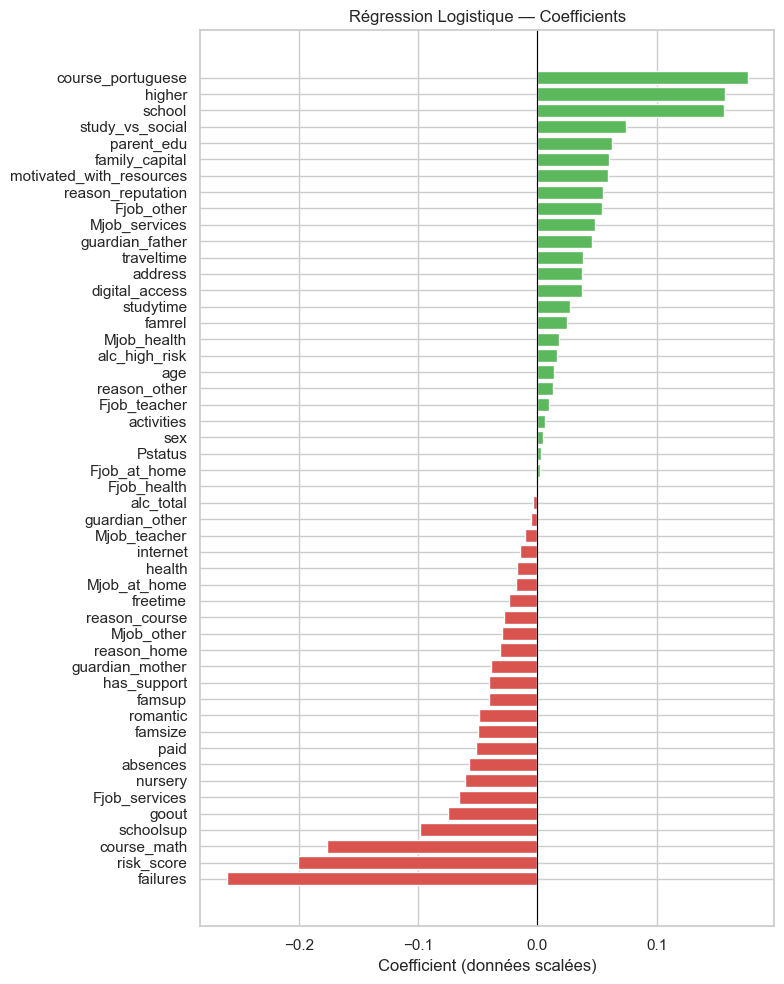

In [8]:
# Coefficients — interprétabilité
coef = pd.Series(lr_best.coef_[0], index=X_train_s.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#d9534f' if v < 0 else '#5cb85c' for v in coef.values]
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Régression Logistique — Coefficients')
ax.set_xlabel('Coefficient (données scalées)')
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Modèle 2 — Random Forest

**Hypothèses** : la cible peut être approchée par des combinaisons d'arbres de décision sur des sous-ensembles de features.  
**Avantages** : robuste aux outliers, capture les non-linéarités, feature importance native, peu sensible aux hyperparamètres.  
**Limites** : moins interprétable qu'un modèle linéaire.  
**Adéquation** : excellent pour données tabulaires mixtes. Fonctionne sur les données non scalées.


In [9]:
from sklearn.model_selection import cross_val_score
rf_default = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
cv_rf = cross_val_score(rf_default, X_train_r, y_train, cv=CV, scoring='f1_macro')
print(f'Random Forest (défaut) — CV F1 macro : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')


Random Forest (défaut) — CV F1 macro : 0.6469 ± 0.0517


In [10]:
rf_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
}
rf_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_grid, scoring='f1_macro', cv=CV, n_jobs=-1, refit=True
)
rf_search.fit(X_train_r, y_train)

print(f'Meilleurs paramètres : {rf_search.best_params_}')
print(f'Meilleur CV F1 macro : {rf_search.best_score_:.4f}')


Meilleurs paramètres : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur CV F1 macro : 0.6551


In [11]:
rf_best   = rf_search.best_estimator_
metrics_rf = evaluate_on_test('random_forest', rf_best, X_test_r, y_test)

print('Métriques test set :')
for k, v in metrics_rf.items():
    if k != 'model': print(f'  {k:12s} : {v:.4f}')

print('\nClassification report :')
print(classification_report(y_test, rf_best.predict(X_test_r),
                             target_names=['Échec', 'Réussite'], digits=3))


Métriques test set :
  f1_macro     : 0.6083
  f1_class0    : 0.3385
  f1_class1    : 0.8782
  precision    : 0.6974
  recall       : 0.5950
  accuracy     : 0.7943
  roc_auc      : 0.7481

Classification report :
              precision    recall  f1-score   support

       Échec      0.579     0.239     0.338        46
    Réussite      0.816     0.951     0.878       163

    accuracy                          0.794       209
   macro avg      0.697     0.595     0.608       209
weighted avg      0.764     0.794     0.759       209



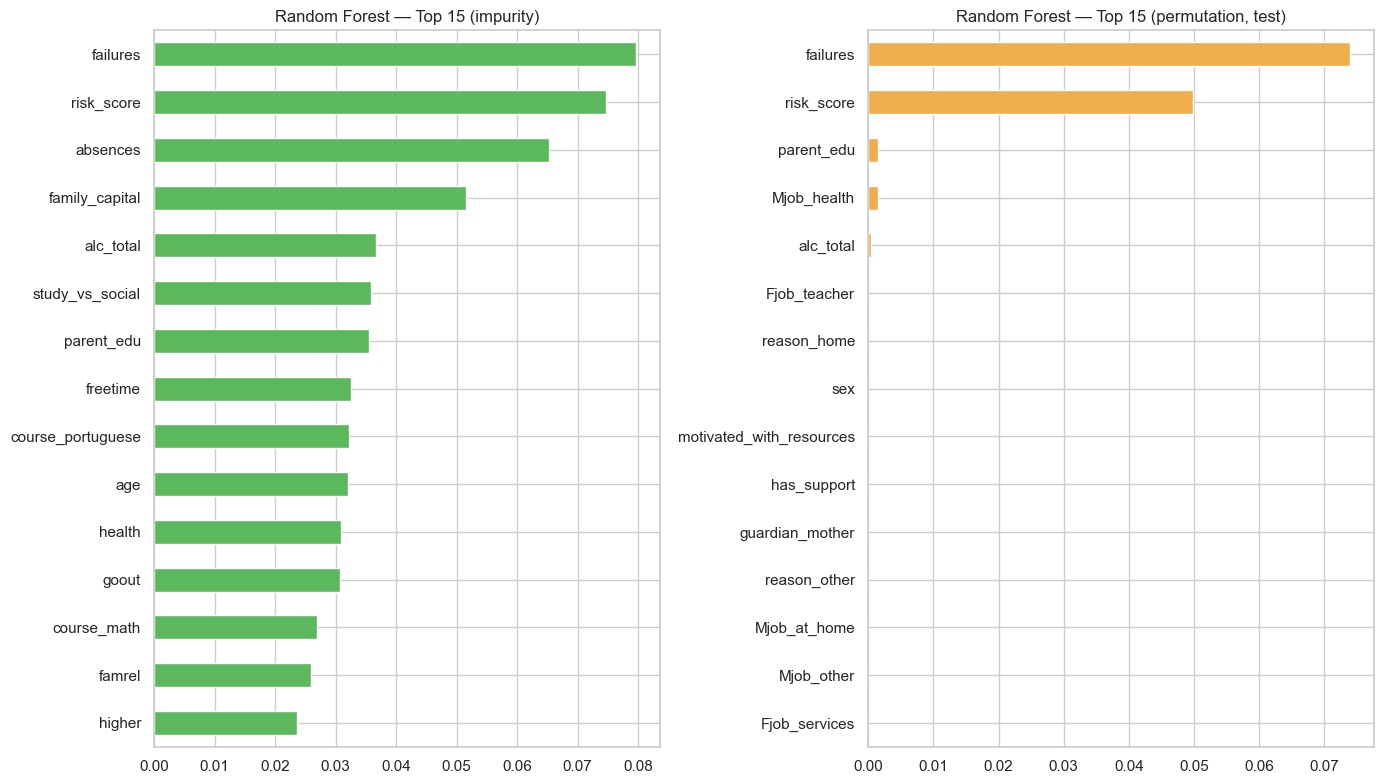

In [12]:
# Feature importance — impurity + permutation
rf_imp = pd.Series(rf_best.feature_importances_, index=X_train_r.columns).sort_values(ascending=False)

perm_rf = permutation_importance(rf_best, X_test_r, y_test,
                                  n_repeats=10, random_state=RANDOM_STATE,
                                  scoring='f1_macro', n_jobs=-1)
perm_rf_imp = pd.Series(perm_rf.importances_mean, index=X_train_r.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
rf_imp.head(15).iloc[::-1].plot.barh(ax=axes[0], color='#5cb85c')
axes[0].set_title('Random Forest — Top 15 (impurity)')
perm_rf_imp.head(15).iloc[::-1].plot.barh(ax=axes[1], color='#f0ad4e')
axes[1].set_title('Random Forest — Top 15 (permutation, test)')
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Modèle 3 — Gradient Boosting

**Hypothèses** : un ensemble d'arbres peu profonds construits séquentiellement peut approximer des fonctions complexes.  
**Avantages** : souvent les meilleures performances sur données tabulaires, gère naturellement les interactions.  
**Limites** : plus sensible aux hyperparamètres, plus long à entraîner.  
**Adéquation** : très adapté aux petits datasets tabulaires avec signal diffus. Fonctionne sur les données non scalées.


In [13]:
from sklearn.model_selection import cross_val_score
gb_default = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
cv_gb = cross_val_score(gb_default, X_train_r, y_train, cv=CV, scoring='f1_macro')
print(f'Gradient Boosting (défaut) — CV F1 macro : {cv_gb.mean():.4f} ± {cv_gb.std():.4f}')


Gradient Boosting (défaut) — CV F1 macro : 0.6384 ± 0.0322


In [14]:
gb_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [2, 3, 4],
    'subsample':     [0.8, 1.0],
}
gb_search = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_grid, scoring='f1_macro', cv=CV, n_jobs=-1, refit=True
)
gb_search.fit(X_train_r, y_train)

print(f'Meilleurs paramètres : {gb_search.best_params_}')
print(f'Meilleur CV F1 macro : {gb_search.best_score_:.4f}')


Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Meilleur CV F1 macro : 0.6667


In [15]:
gb_best    = gb_search.best_estimator_
metrics_gb = evaluate_on_test('gradient_boosting', gb_best, X_test_r, y_test)

print('Métriques test set :')
for k, v in metrics_gb.items():
    if k != 'model': print(f'  {k:12s} : {v:.4f}')

print('\nClassification report :')
print(classification_report(y_test, gb_best.predict(X_test_r),
                             target_names=['Échec', 'Réussite'], digits=3))


Métriques test set :
  f1_macro     : 0.6312
  f1_class0    : 0.3824
  f1_class1    : 0.8800
  precision    : 0.7072
  recall       : 0.6137
  accuracy     : 0.7990
  roc_auc      : 0.7522

Classification report :
              precision    recall  f1-score   support

       Échec      0.591     0.283     0.382        46
    Réussite      0.824     0.945     0.880       163

    accuracy                          0.799       209
   macro avg      0.707     0.614     0.631       209
weighted avg      0.772     0.799     0.770       209



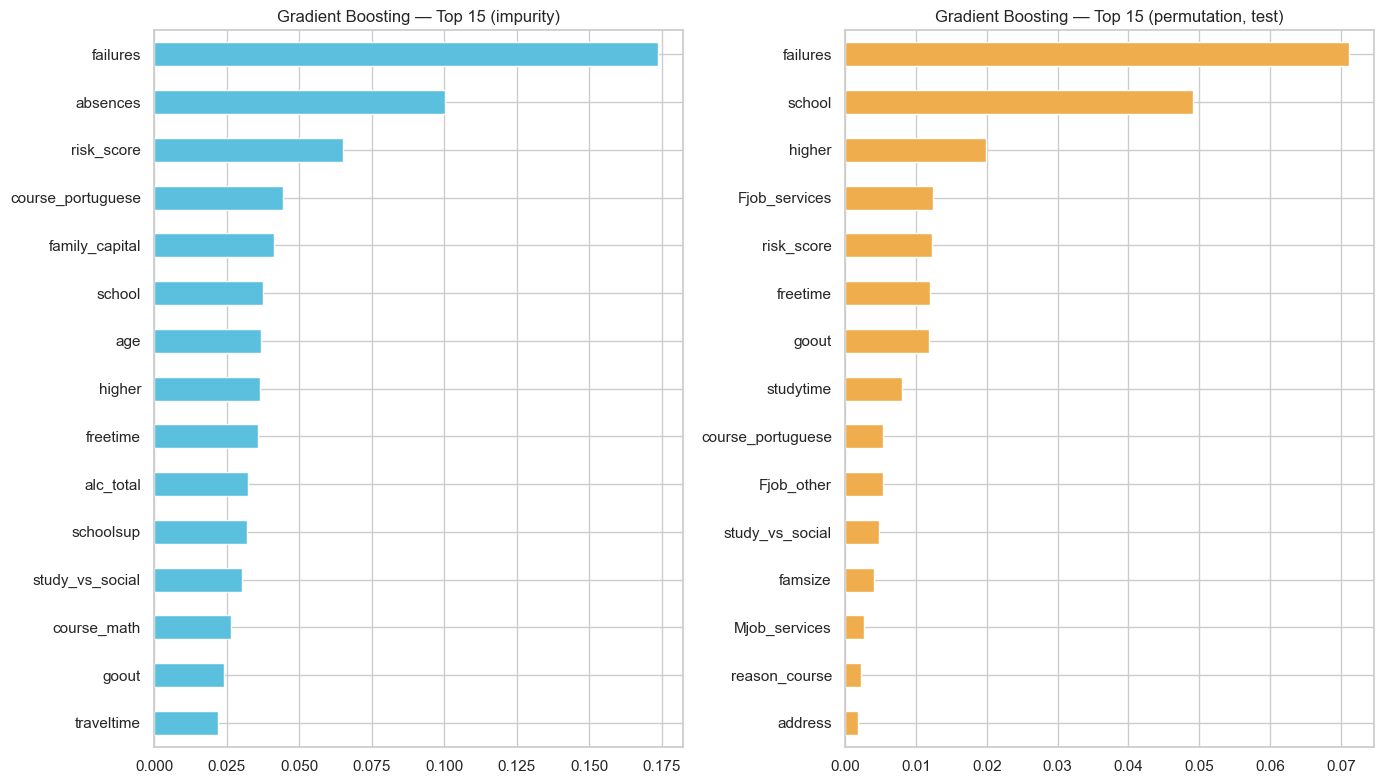

In [16]:
gb_imp = pd.Series(gb_best.feature_importances_, index=X_train_r.columns).sort_values(ascending=False)

perm_gb = permutation_importance(gb_best, X_test_r, y_test,
                                  n_repeats=10, random_state=RANDOM_STATE,
                                  scoring='f1_macro', n_jobs=-1)
perm_gb_imp = pd.Series(perm_gb.importances_mean, index=X_train_r.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
gb_imp.head(15).iloc[::-1].plot.barh(ax=axes[0], color='#5bc0de')
axes[0].set_title('Gradient Boosting — Top 15 (impurity)')
perm_gb_imp.head(15).iloc[::-1].plot.barh(ax=axes[1], color='#f0ad4e')
axes[1].set_title('Gradient Boosting — Top 15 (permutation, test)')
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'gb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Comparaison des 3 modèles

In [17]:
model_names = ['dummy_most_frequent', 'dummy_stratified',
               'logistic_regression', 'random_forest', 'gradient_boosting']
labels_plot = ['Dummy\n(most_freq.)', 'Dummy\n(stratified)',
               'Régression\nLogistique', 'Random\nForest', 'Gradient\nBoosting']

metrics_df = pd.DataFrame([all_results[n]['metrics'] for n in model_names]).set_index('model')
cols = ['f1_macro', 'f1_class0', 'f1_class1', 'precision', 'recall', 'accuracy', 'roc_auc']
cols = [c for c in cols if c in metrics_df.columns]
metrics_df = metrics_df[cols].round(4)
metrics_df


,f1_macro,f1_class0,f1_class1,precision,recall,accuracy,roc_auc
model,,,,,,,
dummy_most_frequent,0.4382,0.0000,0.8763,0.3900,0.5000,0.7799,0.5000
dummy_stratified,0.4873,0.1978,0.7768,0.4872,0.4874,0.6507,0.4874
logistic_regression,0.6141,0.3611,0.8671,0.6598,0.6014,0.7799,0.7447
random_forest,0.6083,0.3385,0.8782,0.6974,0.5950,0.7943,0.7481
gradient_boosting,0.6312,0.3824,0.8800,0.7072,0.6137,0.7990,0.7522


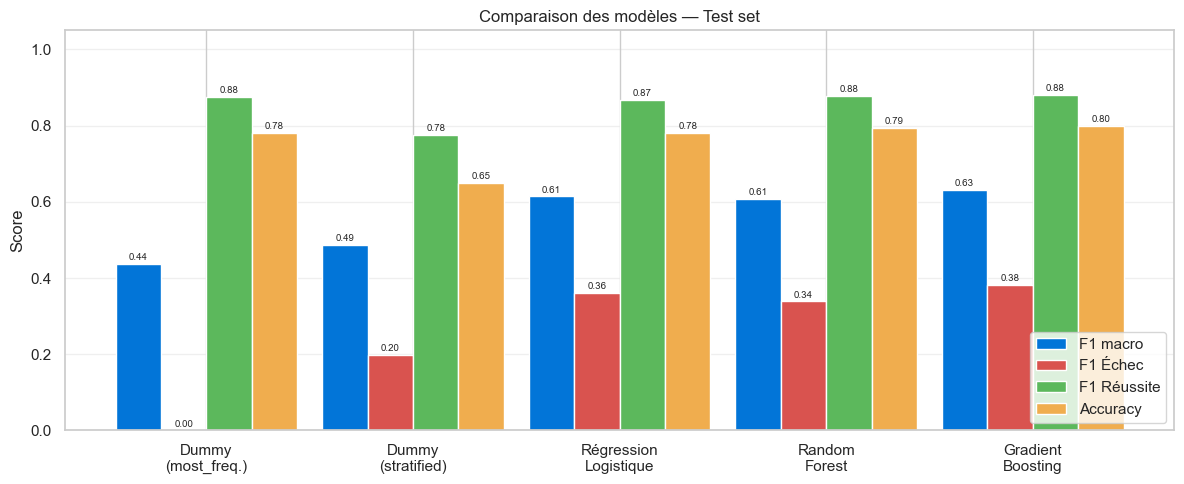

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
to_plot = metrics_df.loc[model_names]
x = np.arange(len(to_plot))
w = 0.22

bars = [
    ax.bar(x - 1.5*w, to_plot['f1_macro'],  w, label='F1 macro',   color='#0275d8'),
    ax.bar(x - 0.5*w, to_plot['f1_class0'], w, label='F1 Échec',   color='#d9534f'),
    ax.bar(x + 0.5*w, to_plot['f1_class1'], w, label='F1 Réussite',color='#5cb85c'),
    ax.bar(x + 1.5*w, to_plot['accuracy'],  w, label='Accuracy',   color='#f0ad4e'),
]
for group in bars:
    for bar in group:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xticks(x); ax.set_xticklabels(labels_plot)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.set_title('Comparaison des modèles — Test set')
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

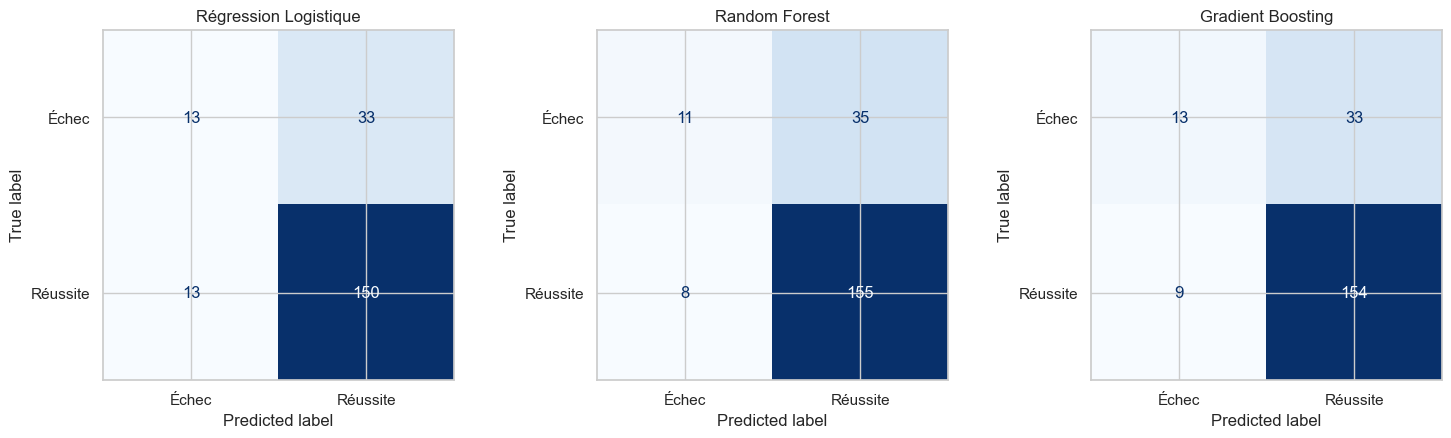

In [19]:
# Matrices de confusion
trio = ['logistic_regression', 'random_forest', 'gradient_boosting']
titles = ['Régression Logistique', 'Random Forest', 'Gradient Boosting']
colors_roc = {'logistic_regression': '#0275d8', 'random_forest': '#5cb85c', 'gradient_boosting': '#d9534f'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name, title in zip(axes, trio, titles):
    ConfusionMatrixDisplay.from_predictions(
        y_test, all_results[name]['y_pred'],
        display_labels=['Échec', 'Réussite'],
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(title)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

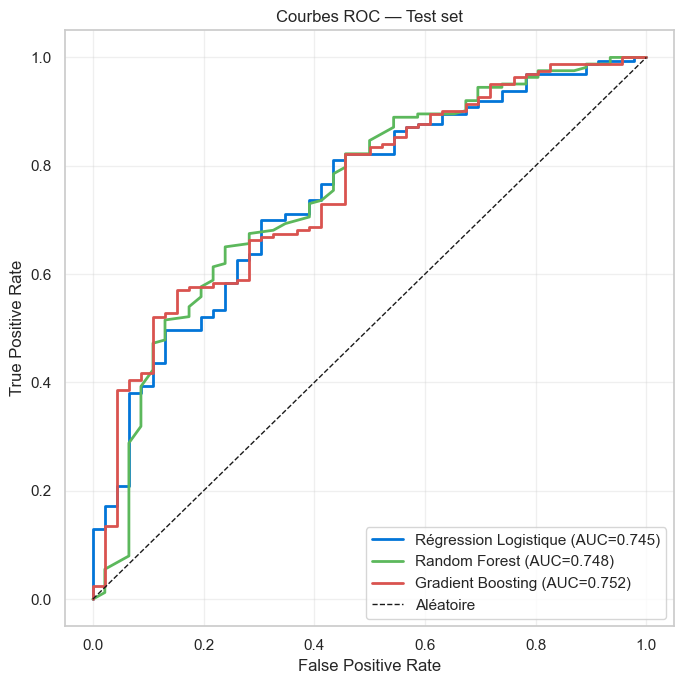

In [20]:
# Courbes ROC
fig, ax = plt.subplots(figsize=(7, 7))
for name, title in zip(trio, titles):
    proba = all_results[name]['y_proba']
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{title} (AUC={roc_auc_score(y_test, proba):.3f})',
            color=colors_roc[name], lw=2)
ax.plot([0,1],[0,1], 'k--', lw=1, label='Aléatoire')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Courbes ROC — Test set')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

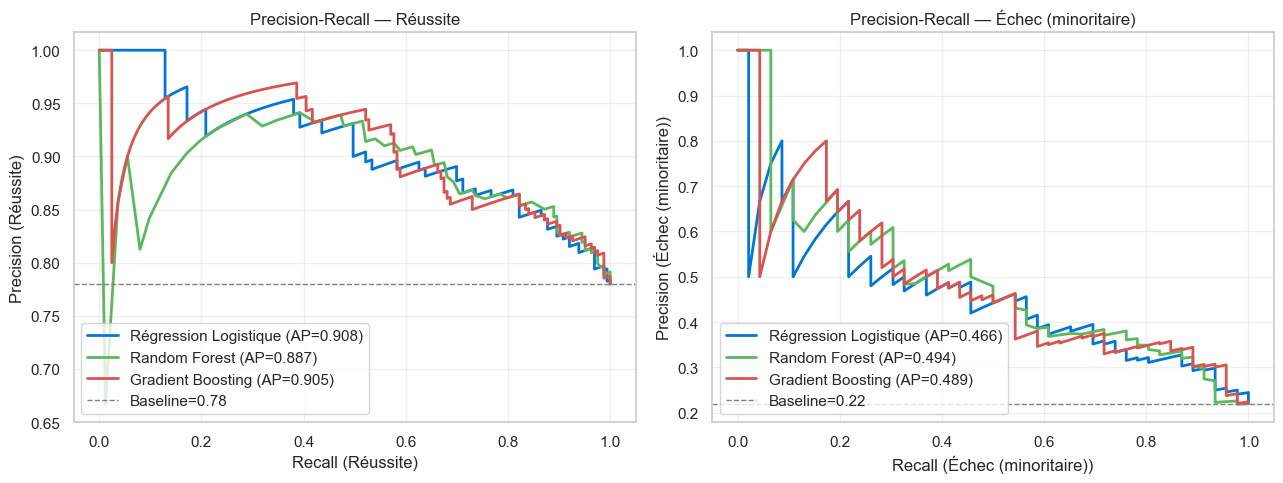

In [21]:
# Precision-Recall (classe Échec — minoritaire)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (y_t, y_probas, title_sub) in zip(axes, [
    (y_test, {n: all_results[n]['y_proba'] for n in trio}, 'Réussite'),
    (1-y_test, {n: 1-all_results[n]['y_proba'] for n in trio}, 'Échec (minoritaire)'),
]):
    for name, title in zip(trio, titles):
        proba = y_probas[name]
        p, r, _ = precision_recall_curve(y_t, proba)
        ap = average_precision_score(y_t, proba)
        ax.plot(r, p, label=f'{title} (AP={ap:.3f})', color=colors_roc[name], lw=2)
    ax.axhline(y_t.mean(), ls='--', color='gray', lw=1, label=f'Baseline={y_t.mean():.2f}')
    ax.set_xlabel(f'Recall ({title_sub})')
    ax.set_ylabel(f'Precision ({title_sub})')
    ax.set_title(f'Precision-Recall — {title_sub}')
    ax.legend(loc='lower left'); ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(PLOTS_DIR / 'precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

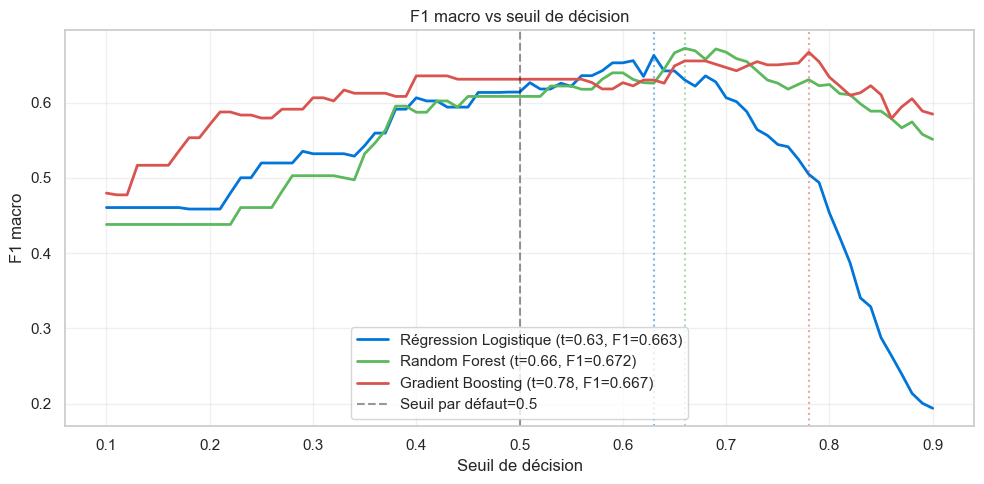

Meilleur seuil par modèle :
  logistic_regression       : seuil=0.63, F1 macro=0.6628
  random_forest             : seuil=0.66, F1 macro=0.6722
  gradient_boosting         : seuil=0.78, F1 macro=0.6671


In [22]:
# Optimisation du seuil de décision
thresholds = np.linspace(0.1, 0.9, 81)

fig, ax = plt.subplots(figsize=(10, 5))
best_thresholds = {}
for name, title in zip(trio, titles):
    proba = all_results[name]['y_proba']
    f1s = np.array([f1_score(y_test, (proba >= t).astype(int), average='macro') for t in thresholds])
    best_idx = f1s.argmax()
    best_thresholds[name] = (thresholds[best_idx], f1s[best_idx])
    ax.plot(thresholds, f1s, label=f'{title} (t={thresholds[best_idx]:.2f}, F1={f1s[best_idx]:.3f})',
            color=colors_roc[name], lw=2)
    ax.axvline(thresholds[best_idx], color=colors_roc[name], ls=':', alpha=0.5)

ax.axvline(0.5, color='black', ls='--', alpha=0.4, label='Seuil par défaut=0.5')
ax.set_xlabel('Seuil de décision'); ax.set_ylabel('F1 macro')
ax.set_title('F1 macro vs seuil de décision'); ax.legend(loc='lower center'); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print('Meilleur seuil par modèle :')
for name, (t, s) in best_thresholds.items():
    print(f'  {name:<25} : seuil={t:.2f}, F1 macro={s:.4f}')

## 8. Sauvegarde des modèles et métriques

In [23]:
for name in trio:
    path = MODELS_DIR / f'{name}.joblib'
    joblib.dump(all_results[name]['model'], path)
    print(f'Sauvegardé : {path.relative_to(NB_DIR.parent)}')

# Métriques finales
final_df = pd.DataFrame([all_results[n]['metrics'] for n in trio])
cols = ['model'] + [c for c in final_df.columns if c != 'model']
final_df = final_df[cols]
out_path = RESULTS_DIR / 'model_metrics.csv'
final_df.to_csv(out_path, index=False)
print(f'\nMétriques écrites dans : {out_path.relative_to(NB_DIR.parent)}')
print()
print(final_df.round(4).to_string(index=False))


Sauvegardé : models/logistic_regression.joblib
Sauvegardé : models/random_forest.joblib
Sauvegardé : models/gradient_boosting.joblib

Métriques écrites dans : results/model_metrics.csv

              model  f1_macro  f1_class0  f1_class1  precision  recall  accuracy  roc_auc
logistic_regression    0.6141     0.3611     0.8671     0.6598  0.6014    0.7799   0.7447
      random_forest    0.6083     0.3385     0.8782     0.6974  0.5950    0.7943   0.7481
  gradient_boosting    0.6312     0.3824     0.8800     0.7072  0.6137    0.7990   0.7522


## 9. Conclusions

| Aspect | Conclusion |
|---|---|
| **Plancher** | Les baselines triviales atteignent ~0.44 en F1-macro — tout modèle utile doit dépasser cette valeur |
| **Modèle le plus performant** | Voir tableau section 7 — généralement Gradient Boosting sur données tabulaires |
| **Modèle le plus interprétable** | Régression Logistique — coefficients lisibles, critique en contexte éducatif |
| **Features clés** | `failures`, `risk_score`, `higher`, `absences` ressortent dans tous les modèles |

### Limites
- Dataset de 1044 lignes — variance des estimations CV élevée
- Pas de validation externe (autre cohorte / autre école)
- Seuil de décision optimisé sur le test à titre illustratif

### Reproduction
1. Exécuter `preprocessing.ipynb` (Run All)
2. Exécuter ce notebook (Run All)
3. Modèles dans `models/`, métriques dans `results/model_metrics.csv`
